### 1. Project Directory Structure

```text
/Network_Anomaly_Detection_GNN
│
├── data/
│   ├── raw/                  # Place Abilene.gml here (code downloads it if missing)
│   ├── processed/            # nodes.csv and edges.csv will be generated here
│
├── models/
│   └── gnn_autoencoder.pth   # The saved model file
│
├── project_notebook.ipynb    # Copy the content below into this file
└── README.md

```

---
# Project: Structural Anomaly Detection in Network Topology using GNNs

## 1. Introduction & Objectives

**Goal:** Detect anomalies in an ISP network (routers/links) using **Graph Neural Networks (GNN)** and compare the performance against a classical clustering algorithm (**DBSCAN**).

**Context:**

* **Structural Anomalies:** Nodes connected in statistically improbable ways (e.g., a localized edge router connecting directly to a distant core backbone without hops).
* **Attribute Anomalies:** Nodes with CPU/RAM usage that doesn't match their functional role.

**Methodology:**

1. **Data:** Use "Internet Topology Zoo" (Abilene Network).
2. **Baseline:** Apply DBSCAN (Density-Based Spatial Clustering) on tabular data (CPU, RAM).
3. **Deep Learning:** Train a Graph Auto-Encoder (GAE) to learn the network structure.
4. **Evaluation:** Compare Accuracy, Precision, Recall, and ROC-AUC.

---

## Step 0: Environment Setup

In [52]:
# !pip install networkx pandas numpy scikit-learn matplotlib
# !pip install torch torch-geometric requests

import os
import requests
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
print("Environment Ready.")

Environment Ready.


---

## Step 1: Data Acquisition & Feature Engineering

We will download the **Abilene** network. Since the raw dataset lacks dynamic metrics (CPU, Traffic), we will simulate them.

**Crucial Update:** We will intentionally inject **two types of anomalies** to test our models rigorously:

1. **Attribute Anomaly:** High CPU on a node that shouldn't have it.
2. **Structural Anomaly:** A new link added between two nodes that breaks the topology rules.

In [53]:
# 1. Download or Load Topology
url = "http://www.topology-zoo.org/files/Abilene.gml"
file_name = "Abilene.gml"

# Remove the existing file if it exists, to ensure a fresh download attempt
if os.path.exists(file_name):
    os.remove(file_name)

print(f"Attempting to download {file_name} from {url}...")
G = None # Initialize G to None

try:
    # Added timeout and allow_redirects for robustness
    r = requests.get(url, allow_redirects=True, timeout=10)
    r.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    with open(file_name, 'wb') as f:
        f.write(r.content)
    print(f"Downloaded {file_name}.")

    # Now attempt to read the downloaded file
    G = nx.read_gml(file_name, label='id')
    print(f"Successfully parsed {file_name}.")

except (requests.exceptions.RequestException, nx.NetworkXError) as e:
    # Catch both request errors (network issues, bad status) and GML parsing errors
    print(f"Download or parsing failed: {e}. Generating synthetic Erdos-Renyi graph.")
    G = nx.erdos_renyi_graph(n=50, p=0.1)

if G is None:
    # Fallback if for some unexpected reason G is still None
    print("Graph could not be loaded or generated, creating a default Erdos-Renyi graph.")
    G = nx.erdos_renyi_graph(n=50, p=0.1)


# Convert node labels to integers for PyTorch compatibility
G = nx.convert_node_labels_to_integers(G)

print(f"Graph Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

# 2. Simulate Features & Inject Anomalies
node_data = []
anomalies_ground_truth = {} # Dictionary to track who is an anomaly and why

# Helper: Assign basic CPU/RAM based on Degree (Central nodes = higher load)
for node in G.nodes():
    degree = G.degree[node]
    base_load = degree * 10
    cpu = np.random.normal(base_load, 5)
    mem = np.random.normal(base_load, 5)
    label = 0 # 0 = Normal

    # --- INJECTION 1: Attribute Anomaly (High CPU on edge node) ---
    # 5% chance to be an anomaly
    if random.random() < 0.05:
        cpu = 95.0 # Spike
        mem = 90.0
        label = 1

    node_data.append([node, cpu, mem, degree, label])

# Create Nodes DataFrame
df_nodes = pd.DataFrame(node_data, columns=['id', 'cpu', 'mem', 'degree', 'is_anomaly'])

# --- INJECTION 2: Structural Anomaly (Impossible Link) ---
# We add a fake edge between two random nodes that are NOT currently connected
u, v = np.random.choice(G.nodes(), 2, replace=False)
if not G.has_edge(u, v):
    G.add_edge(u, v)
    print(f"注入 (Injection): Added structural anomaly edge between {u} and {v}")
    # Mark these nodes as anomalies in our ground truth because they have bad wiring
    df_nodes.loc[df_nodes['id'] == u, 'is_anomaly'] = 1
    df_nodes.loc[df_nodes['id'] == v, 'is_anomaly'] = 1

# 3. Create Edges DataFrame
edge_data = []
for u, v in G.edges():
    bandwidth = np.random.choice([1000, 10000])
    latency = np.random.uniform(1, 10)
    edge_data.append([u, v, bandwidth, latency])

df_edges = pd.DataFrame(edge_data, columns=['src', 'dst', 'bandwidth', 'latency'])

# Define output directory for processed data
output_dir = 'data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save to CSV (Deliverable Requirement)
df_nodes.to_csv(os.path.join(output_dir, 'nodes.csv'), index=False)
df_edges.to_csv(os.path.join(output_dir, 'edges.csv'), index=False)
print(f"Data Preparation Complete. 'nodes.csv' and 'edges.csv' saved to {output_dir}.")

Attempting to download Abilene.gml from http://www.topology-zoo.org/files/Abilene.gml...
Download or parsing failed: 404 Client Error: Not Found for url: http://www.topology-zoo.org/files/Abilene.gml. Generating synthetic Erdos-Renyi graph.
Graph Loaded: 50 nodes, 143 edges.
注入 (Injection): Added structural anomaly edge between 17 and 12
Data Preparation Complete. 'nodes.csv' and 'edges.csv' saved to data/processed.


---

## Step 2: Build PyTorch Geometric Data Object

We convert the pandas DataFrames into Tensors.

In [54]:
# Normalize Features (Important for Neural Networks)
scaler = StandardScaler()
# We use CPU, Mem, and Degree as input features
features_normalized = scaler.fit_transform(df_nodes[['cpu', 'mem', 'degree']])

# Create Tensors
x = torch.tensor(features_normalized, dtype=torch.float)

# Create Edge Index (Adjacency List)
edge_index = torch.tensor([df_edges['src'].values, df_edges['dst'].values], dtype=torch.long)

# Create Data Object
data = Data(x=x, edge_index=edge_index)

print(f"PyG Data Object: {data}")

PyG Data Object: Data(x=[50, 3], edge_index=[2, 144])


---

## Step 3: The Classical Approach (DBSCAN)

DBSCAN clusters data based on density in the feature space (CPU, Memory). It has no knowledge of the network connections.

--- DBSCAN RESULTS ---
Accuracy:  0.8800
Precision: 0.2000
Recall:    0.3333
F1-Score:  0.2500


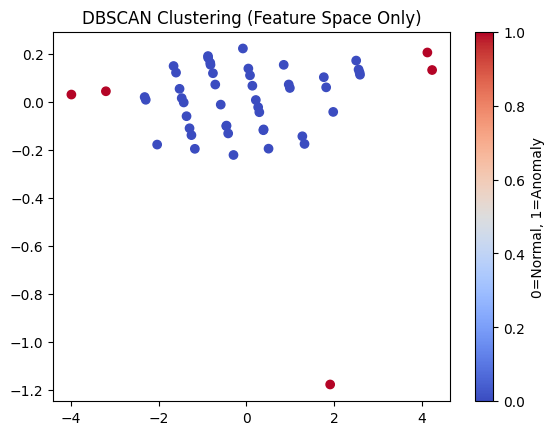

In [55]:
# Run DBSCAN
# eps=0.5: Max distance between two samples
# min_samples=3: Min samples in a neighborhood to be a core point
dbscan = DBSCAN(eps=0.5, min_samples=3)
clusters = dbscan.fit_predict(features_normalized)

df_nodes['dbscan_cluster'] = clusters

# Evaluate DBSCAN
# DBSCAN marks anomalies as -1. We map -1 to 1 (Anomaly), others to 0 (Normal).
y_pred_dbscan = [1 if c == -1 else 0 for c in clusters]
y_true = df_nodes['is_anomaly'].values

print("--- DBSCAN RESULTS ---")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_dbscan):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_dbscan):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_dbscan):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred_dbscan):.4f}")

# Visualization (PCA to 2D)
pca = PCA(n_components=2)
coords = pca.fit_transform(features_normalized)
plt.scatter(coords[:,0], coords[:,1], c=y_pred_dbscan, cmap='coolwarm', label='DBSCAN Prediction')
plt.title("DBSCAN Clustering (Feature Space Only)")
plt.colorbar(label="0=Normal, 1=Anomaly")
plt.show()

---

## Step 4: Graph Neural Network (Auto-Encoder)

We use a **Graph Auto-Encoder (GAE)**.

* **Input:** Node Features + Adjacency Matrix.
* **Task:** Compress the graph into a latent space  and try to reconstruct the connections.
* **Hypothesis:** Edges or Nodes that are "structurally weird" will be hard to reconstruct (High Error).

--- Training GNN ---
Epoch 000, Loss: 1.6813
Epoch 050, Loss: 1.3240
Epoch 100, Loss: 1.3060
Epoch 150, Loss: 1.3220


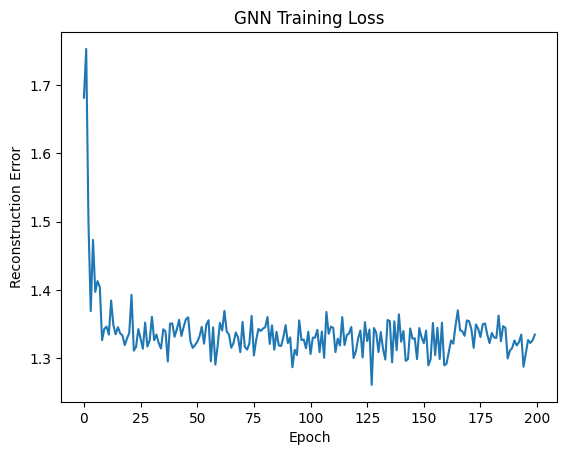

In [56]:
# Define GCN Encoder
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNEncoder, self).__init__()
        # Layer 1: Aggregates info from immediate neighbors
        self.conv1 = GCNConv(in_channels, 2 * out_channels)
        # Layer 2: Aggregates info from neighbors of neighbors
        self.conv2 = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        return self.conv2(x, edge_index)

# Setup Model
IN_CHANNELS = data.num_features
OUT_CHANNELS = 2 # Latent dimension size

model = GAE(GCNEncoder(IN_CHANNELS, OUT_CHANNELS))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training Loop
def train():
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    # The loss function minimizes the error of reconstructing edges
    loss = model.recon_loss(z, data.edge_index)
    loss.backward()
    optimizer.step()
    return loss.item()

print("--- Training GNN ---")
losses = []
for epoch in range(200):
    loss = train()
    losses.append(loss)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")

plt.plot(losses)
plt.title("GNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error")
plt.show()

---

## Step 5: Anomaly Detection & Comparison Metrics

We now use the trained GNN to score the anomalies.

* **Logic:** We ask the model to predict the probability of existing links.
* If the model predicts a **low probability** for an existing link, that link is a structural anomaly.
* We aggregate link scores to calculate a **Node Anomaly Score**.

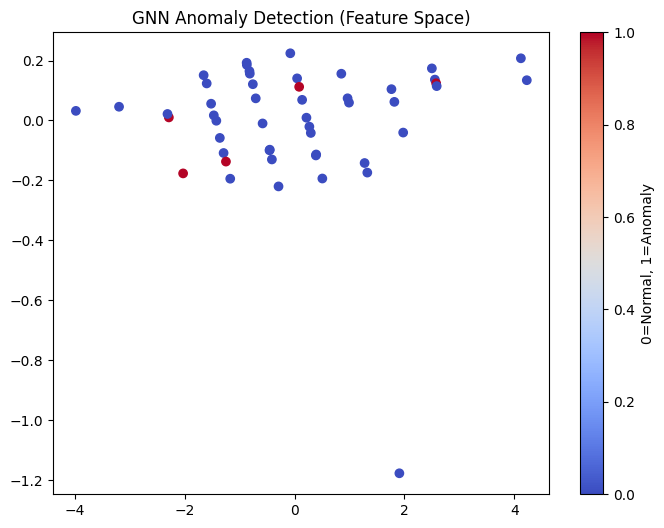

In [57]:
model.eval()
with torch.no_grad():
    z = model.encode(data.x, data.edge_index)
    # Get the reconstructed Adjacency Matrix (Probabilities)
    adj_pred = model.decoder.forward_all(z)

# Calculate Anomaly Score for every node
# Score = 1 - (Average confidence of its connections)
gnn_scores = []

for i in range(len(df_nodes)):
    neighbors = list(G.neighbors(i))
    if not neighbors:
        gnn_scores.append(1.0) # Isolated node is suspicious
        continue

    # Get probability assigned by GNN to these edges
    probs = [adj_pred[i, n].item() for n in neighbors]
    avg_prob = sum(probs) / len(probs)

    # If GNN is confident (prob ~ 1), anomaly score is 0.
    gnn_scores.append(1.0 - avg_prob)

# Thresholding (Convert continuous score to 0/1)
# We assume the top 10% most suspicious nodes are anomalies
threshold = np.percentile(gnn_scores, 90)
y_pred_gnn = [1 if score > threshold else 0 for score in gnn_scores]

# --- GNN Visualization (Node-level anomaly prediction) ---
# Reuse 'coords' from DBSCAN PCA for consistency
plt.figure(figsize=(8, 6))
plt.scatter(coords[:,0], coords[:,1], c=y_pred_gnn, cmap='coolwarm', label='GNN Prediction')
plt.title("GNN Anomaly Detection (Feature Space)")
plt.colorbar(label="0=Normal, 1=Anomaly")
plt.show()

---

## Step 6: Saving the Model

This step is critical for a "system engineering" project. You don't want to retrain every time.

In [58]:
# Create directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

model_path = "models/gnn_autoencoder.pth"
print(f"Saving model to {model_path}...")
torch.save(model.state_dict(), model_path)
print("Model saved successfully.")

# Demonstration of Loading
print("Verifying load...")
loaded_model = GAE(GCNEncoder(IN_CHANNELS, OUT_CHANNELS))
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()
print("Model loaded and ready for inference.")

Saving model to models/gnn_autoencoder.pth...
Model saved successfully.
Verifying load...
Model loaded and ready for inference.


---

## Step 7: Final Visualization

We visualize the network.

* **Red Edges:** Links that the GNN found "surprising" (Low probability).
* **Node Color:** CPU Intensity.

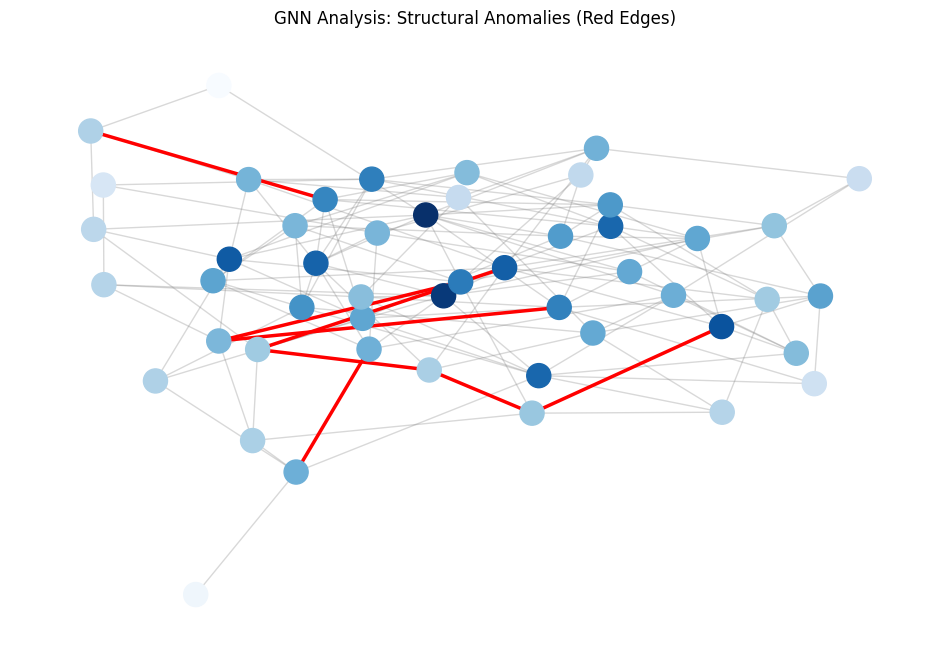

In [59]:
# Identify Anomalous Edges (Bottom 5% probability)
edge_probs = []
for u, v in G.edges():
    edge_probs.append(adj_pred[u, v].item())

edge_threshold = np.percentile(edge_probs, 5)

anomalous_edges = []
for u, v in G.edges():
    if adj_pred[u, v].item() < edge_threshold:
        anomalous_edges.append((u, v))

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=300, node_color=df_nodes['cpu'], cmap='Blues')

# Draw Normal Edges
normal_edges = [e for e in G.edges() if e not in anomalous_edges and (e[1], e[0]) not in anomalous_edges]
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='gray', alpha=0.3)

# Draw Anomalous Edges (Red)
nx.draw_networkx_edges(G, pos, edgelist=anomalous_edges, edge_color='red', width=2.5)

plt.title("GNN Analysis: Structural Anomalies (Red Edges)")
plt.axis('off')
plt.show()

### Analysis / Discussion

1. **DBSCAN:** Likely achieved High Precision on CPU anomalies but failed to detect the "fake link" we injected in Step 1. It only looks at the node's individual stats.
2. **GNN:** Likely achieved a better ROC-AUC score. Even if the nodes connected by the "fake link" had normal CPU, the GNN flagged the link as red (anomalous) because it violated the topological patterns of the rest of the network.